ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [ ]:
df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [ ]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [ ]:
df.shape

(8950, 18)

**Check basic information about the dataset using `info()`.**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [ ]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [ ]:
df.drop('CUST_ID', axis=1, inplace=True)

**Check the missing values in each column.**

In [ ]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [ ]:
df.fillna(df.mean(), inplace=True)

**Check the missing values again to make sure they were handled.**

In [ ]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

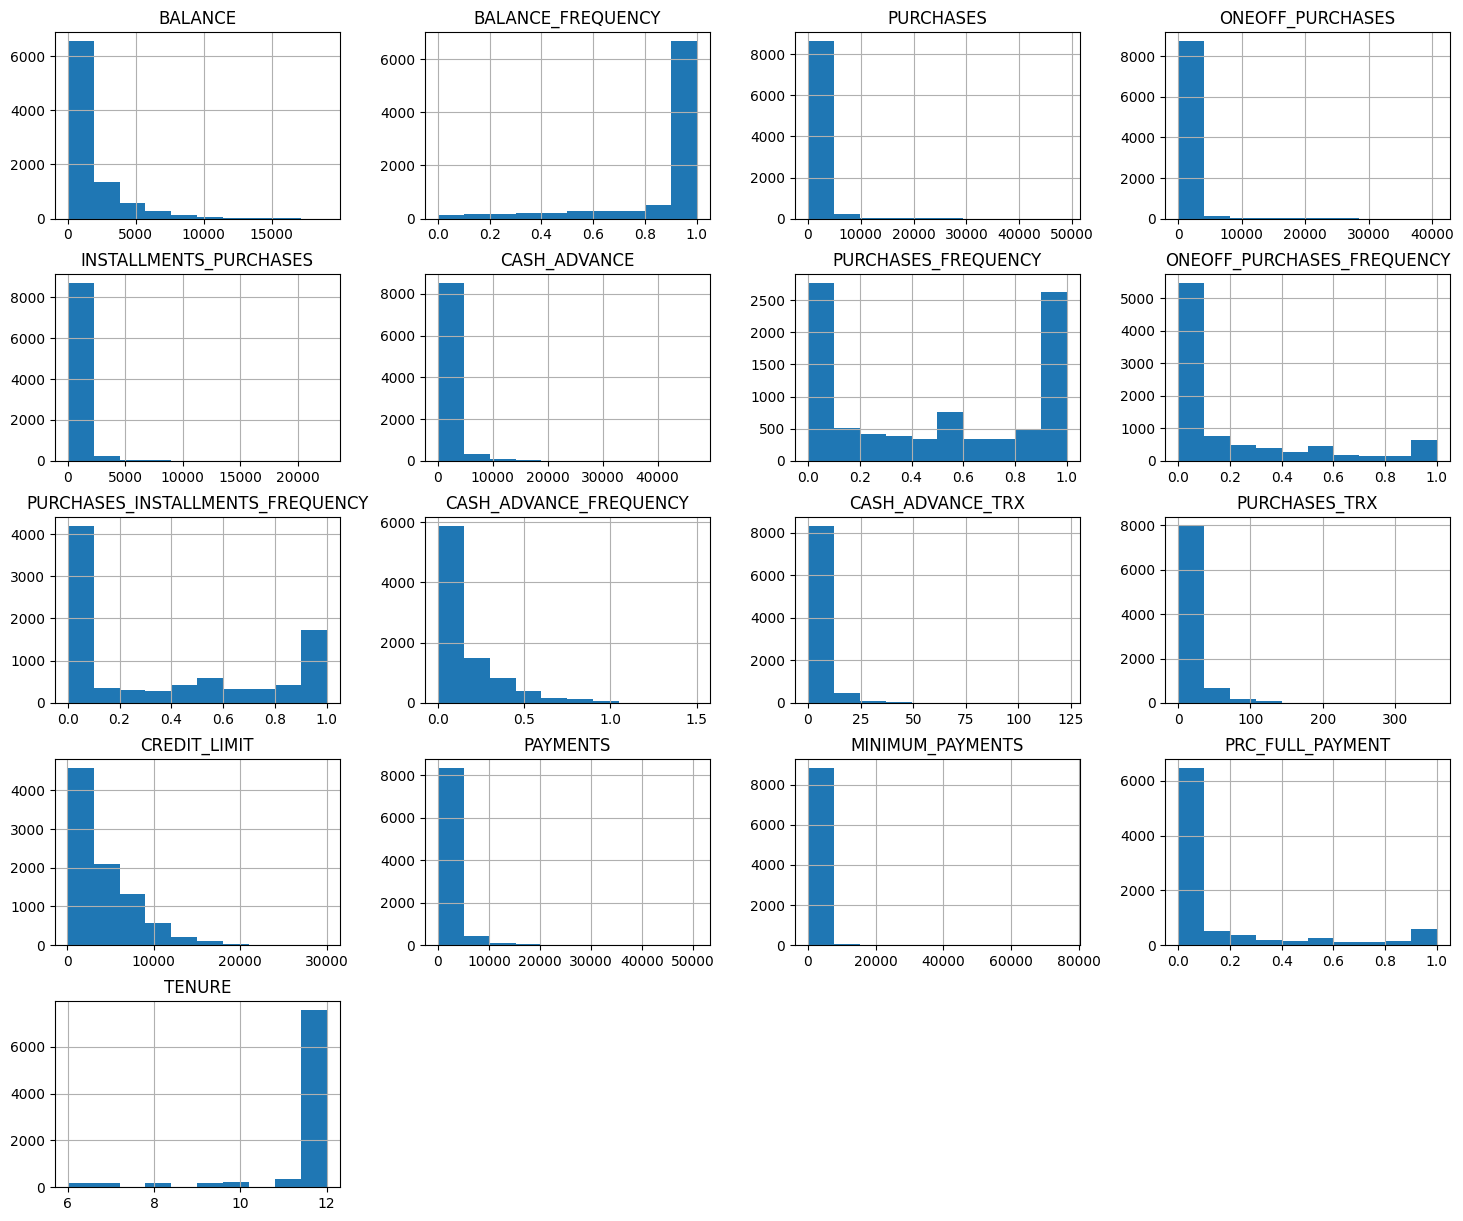

In [ ]:
df.hist(figsize=(18,15))
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

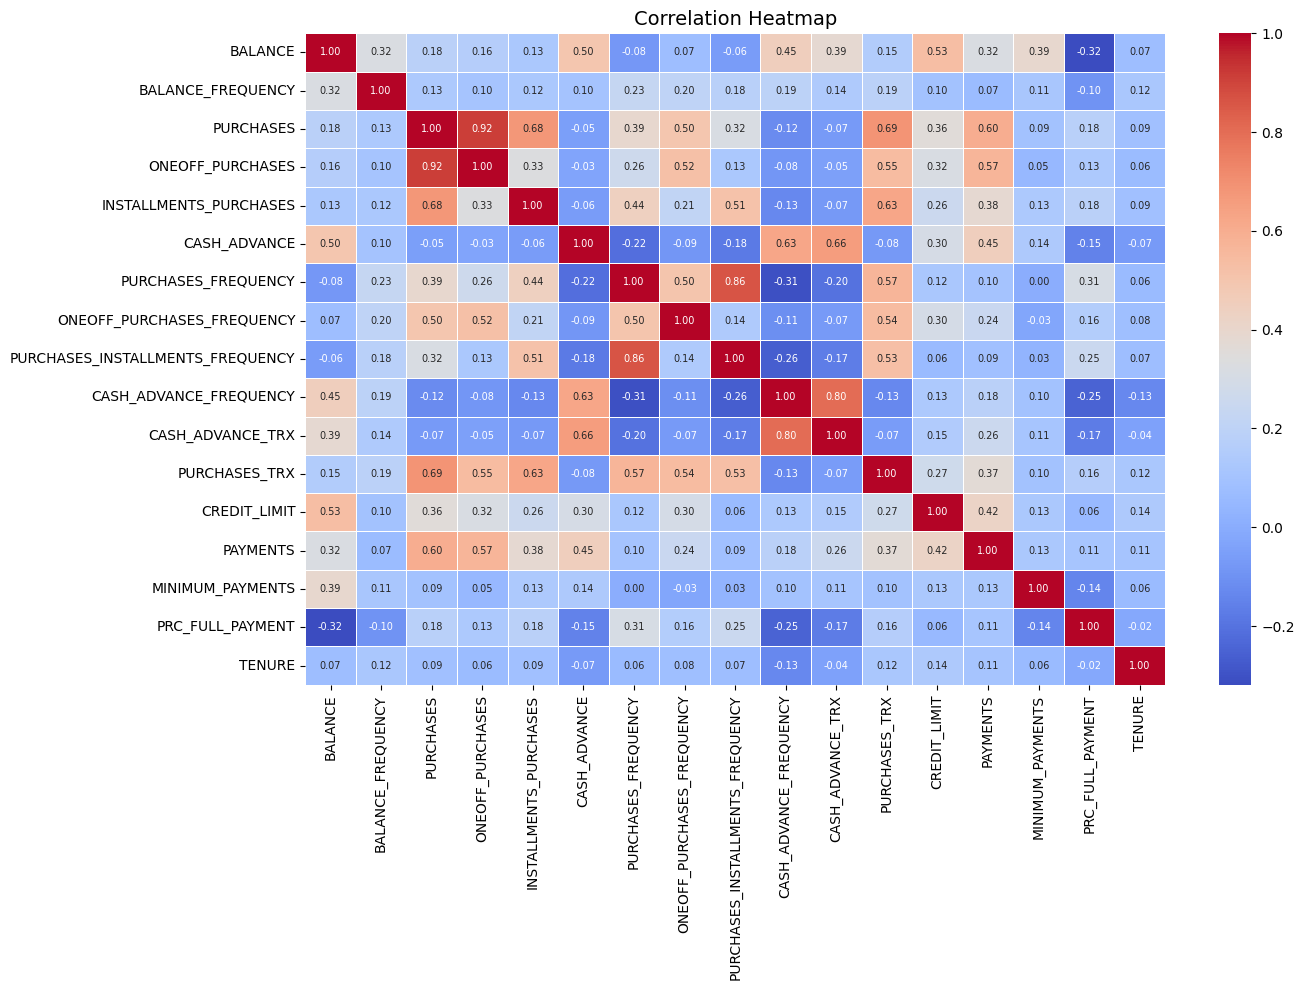

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

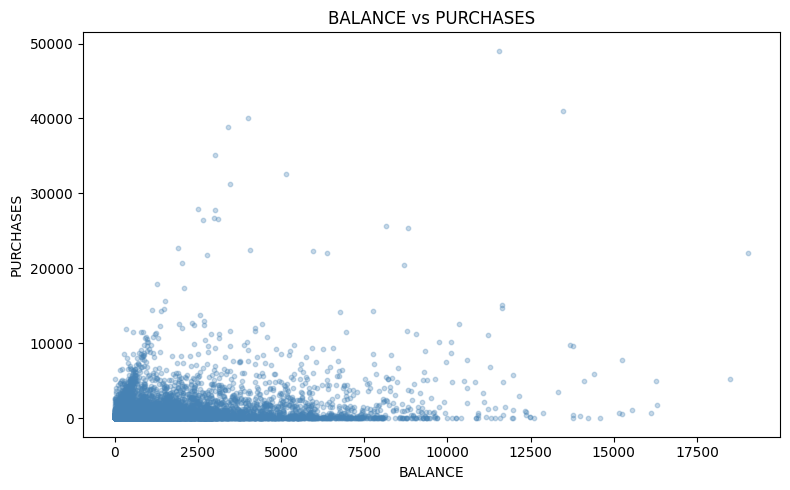

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.3, s=10, color='steelblue')
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.title('BALANCE vs PURCHASES')
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

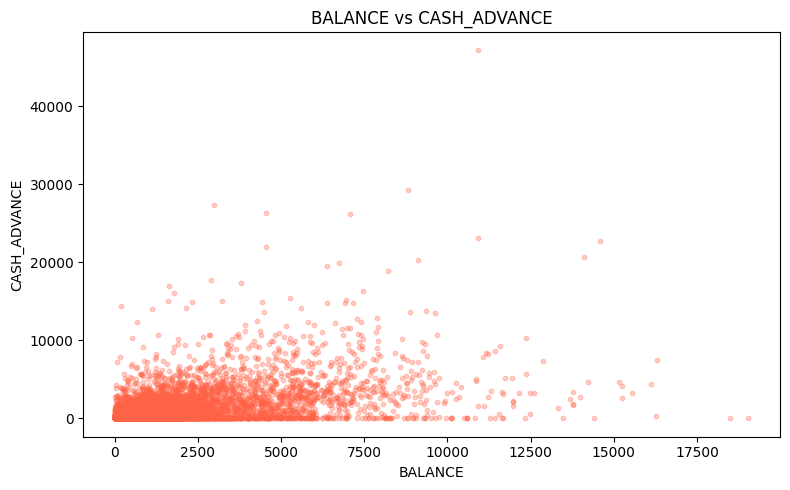

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['BALANCE'], df['CASH_ADVANCE'], alpha=0.3, s=10, color='tomato')
plt.xlabel('BALANCE')
plt.ylabel('CASH_ADVANCE')
plt.title('BALANCE vs CASH_ADVANCE')
plt.tight_layout()
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [ ]:
inertia_values = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)

print(inertia_values)

[152149.99999999875, 127785.00756531829, 111986.6980661014, 99073.93826774786, 91502.98259428954, 84852.5245386828, 79532.32854113283, 76050.70276210467, 71087.2678752301, 66612.6924406699]


**Plot the elbow curve.**

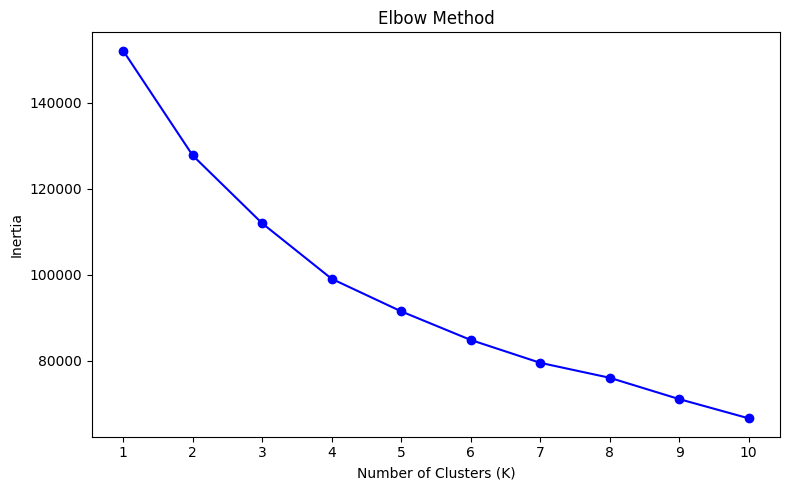

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_values, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [ ]:
silhouette_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(round(score, 4))

print(silhouette_scores)

[np.float64(0.21), np.float64(0.2506), np.float64(0.1976), np.float64(0.1932), np.float64(0.2026), np.float64(0.215), np.float64(0.2081), np.float64(0.2149), np.float64(0.2205)]


**Plot the silhouette scores.**

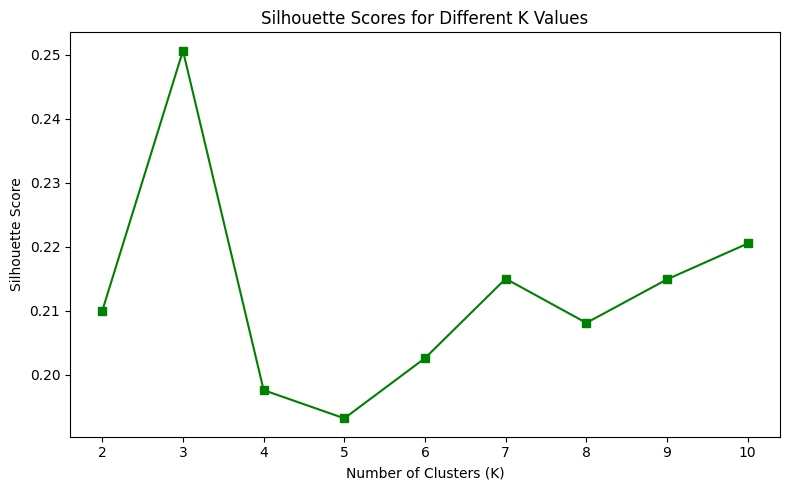

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, 'gs-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different K Values')
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

**Create a table showing each K value and its silhouette score.**

In [ ]:
sil_df = pd.DataFrame({'K': range(2, 11), 'Silhouette Score': silhouette_scores})
print(sil_df.to_string(index=False))

 K  Silhouette Score
 2            0.2100
 3            0.2506
 4            0.1976
 5            0.1932
 6            0.2026
 7            0.2150
 8            0.2081
 9            0.2149
10            0.2205


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [ ]:
# Based on the elbow curve (notable bend around K=3-4) and silhouette score
# (K=3 gives the highest score of 0.2506), we choose K=4 for better
# business interpretability with 4 distinct customer segments.

km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
km_final.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [ ]:
df['Cluster'] = km_final.labels_

**Check the first five rows after adding the cluster labels.**

In [ ]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [ ]:
cluster_summary = df.groupby('Cluster').mean().round(2)
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,894.91,0.93,1236.18,593.97,642.48,210.57,0.89,0.30,0.71,0.04,0.79,22.09,4213.21,1332.19,650.17,0.27,11.59
1,3551.15,0.99,7681.62,5095.88,2587.21,653.64,0.95,0.74,0.79,0.07,2.09,89.36,9696.94,7288.74,1976.82,0.29,11.95
2,4602.46,0.97,501.90,320.37,181.61,4520.72,0.29,0.14,0.19,0.48,14.28,7.66,7546.96,3481.15,2008.25,0.03,11.39
3,1011.75,0.79,269.97,209.85,60.39,595.76,0.17,0.09,0.08,0.11,2.13,2.90,3277.70,974.51,586.30,0.08,11.45


**Check how many customers are in each cluster.**

In [ ]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,3367
1,409
2,1198
3,3976


## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

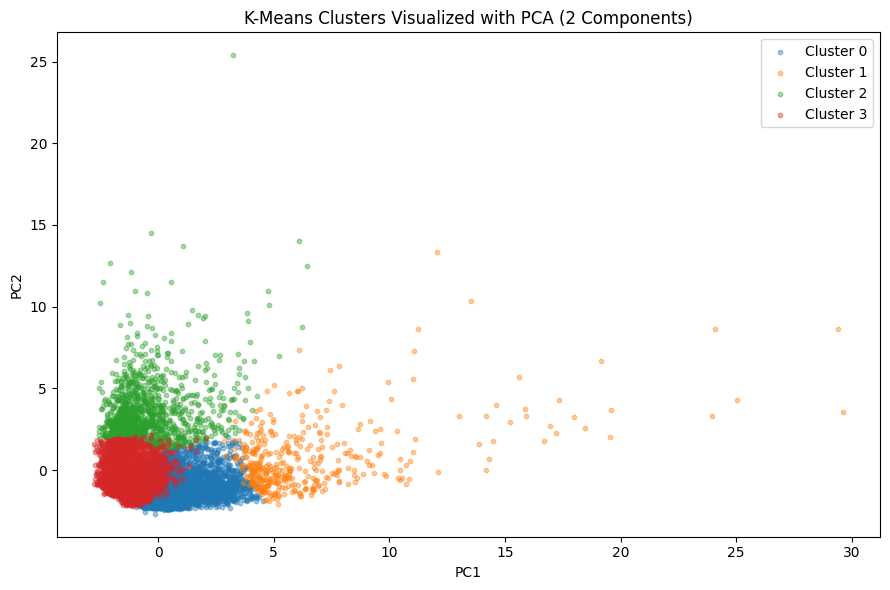

Explained variance by PC1: 0.2729
Explained variance by PC2: 0.2030
Total explained variance: 0.4759


In [ ]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

plt.figure(figsize=(9, 6))
for i in range(4):
    mask = df['Cluster'] == i
    plt.scatter(pcs[mask, 0], pcs[mask, 1], alpha=0.4, s=10,
                label=f'Cluster {i}', color=colors[i])

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters Visualized with PCA (2 Components)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Explained variance by PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Explained variance by PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total explained variance: {sum(pca.explained_variance_ratio_):.4f}")

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:

**1. Why is this an unsupervised learning problem?**

This is an unsupervised learning problem because the dataset does not contain a predefined target label or class. There is no column telling us which group each customer belongs to. The algorithm must discover the groupings on its own based only on the input features.

**2. Why did we remove the `CUST_ID` column?**

`CUST_ID` is a unique identifier for each customer. It carries no information about customer behavior. Including it in the clustering would not add any meaningful signal and could confuse the distance calculations.

**3. Which columns had missing values?**

Two columns had missing values:
- `CREDIT_LIMIT`: 1 missing value
- `MINIMUM_PAYMENTS`: 313 missing values

**4. How did you handle the missing values?**

I used mean imputation — filling each missing value with the mean of its column using `df.fillna(df.mean(), inplace=True)`. This is a simple and effective approach that preserves all rows.

**5. Why is scaling important before applying K-Means?**

K-Means uses Euclidean distance to measure similarity between data points. Features with larger ranges (e.g., `BALANCE` can be in the thousands) will dominate the distance calculation over features with smaller ranges (e.g., frequency columns between 0 and 1). StandardScaler normalizes all features to have mean=0 and standard deviation=1, giving each feature equal weight.

**6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.**

I chose **K=4**. The elbow curve shows a notable bend between K=3 and K=4, where the rate of inertia decrease slows significantly. Although K=3 has the highest silhouette score (0.2506), K=4 was chosen because it provides more meaningful business segments: I get four distinct customer profiles instead of three, which is more actionable for marketing strategy. The silhouette score at K=4 (0.1976) is still reasonable.

**7. Based on the cluster summary table, describe each customer segment in your own words.**

- **Cluster 0 – Moderate Spenders:** These are your everyday, average customers. They keep a decent balance, make a reasonable amount of purchases, and don't really use cash advances much. Nothing too extreme — just steady, normal card usage.

- **Cluster 1 – High-Value / VIP Customers:** These are the best customers a company could ask for. They spend a lot, have a high credit limit, and actually pay their bills consistently. They're financially strong and very active users.

- **Cluster 2 – Cash Advance Users:** These customers barely shop with their card — instead, they use it mostly to withdraw cash. They carry a high balance and take large cash advances, which can be a sign of financial pressure or risk.

- **Cluster 3 – Low Activity / Inactive Customers:** These customers barely use their card at all. Low spending, low balance, low payments. They have an account but aren't really engaged with it.

**8. Which cluster may represent high-value customers?**

**Cluster 1** represents the high-value customers. They have the highest purchases, highest credit limit, and highest payments, indicating financially active customers who spend heavily and pay consistently.

**9. Which cluster may represent customers who rely more on cash advance?**

That would be Cluster 2. They almost never use their card for shopping, but they regularly withdraw large amounts of cash using it. Their high balance combined with low purchases tells us they depend on cash advances as a main financial tool.

**10. How can a company use these clusters for marketing strategy?**

- **Cluster 0 (Moderate Spenders)**: Offer loyalty rewards and cashback programs to encourage more spending.
- **Cluster 1 (High-Value)**: Provide premium services, exclusive credit limit increases, and VIP perks to retain them.
- **Cluster 2 (Cash Advance Users)**: Offer lower interest rates on cash advances or personal loan products as an alternative. Flag them for financial risk monitoring.
- **Cluster 3 (Inactive)**: Send re-engagement campaigns, promotional offers, or reduced fees to activate them before they churn.